# Регуляризация модели

В рамках вводного курса мы обсудили вопрос разделения выборки на обучающую и
тестовую части, а также затронули проблему переобучения и недообучения модели.
Рассмотрим этот вопрос более подробно.

## Переобучение и недообучение модели
**Переобучение** (overfitting) случается, когда модель показывает хороший
результат на обучающей выборке и сильно «проседает» на тестовых данных. При
**недообучени**и (underfitting) наоборот у алгоритма не получается уловить
зависимость на обучающих данных.

Вспомним график из вводного курса.

![](https://drive.google.com/uc?export=view&id=1AyFOXYlCg75iDeLnq2OHmllditpdsyhx)

Дополним его для наглядности иллюстрацией того, как может повести себя
переобученная модель на тестовых данных.
![](https://drive.google.com/uc?export=view&id=1EIcOnHGx3pKpk2wyKqoptAAvIj0txsch)

Также рассмотрим пример переобучения и недообучения в задаче классификации.
![](https://drive.google.com/uc?export=view&id=1HIHfbUdXdMsciF7IoPBjSKzBtisahacg)

Приведем еще один график. Предположим, что мы взяли полиномиальную
регрессию и смотрим на значение функции потерь на обучающих и тестовых
данных для различных степеней полинома.

![](https://drive.google.com/uc?export=view&id=1wUe-8DdsLvx68R5MwYczOjww4DCpV7Te)

Как вы видите, после определенной границы *сложности модели* ошибка на
тестовых данных начала расти. Рассмотрим этот вопрос под разными углами и
введем несколько новых терминов.

### Сложность модели
Причиной пере- и недообучения может быть степень сложности используемой
модели (model complexity). Под сложностью в данном случае понимается тип или
типы используемых алгоритмов, способность к выявлению линейных или
нелинейных зависимостей, количество рассматриваемых признаков и другие факторы.

В целом, можно сказать, что более простая модель склонна к недообучению,
более сложная — к переобучению.

Например, полиномиальная модель (особенно с полиномом высокой степени)
зачастую способна уловить более сложную зависимость, чем модель линейной
регрессии. Если модель хорошо описывает исходные данные, говорят, что у нее
низкое смещение.

#### Смещение
**Cмещение** (bias) представляет собой разность между истинным и прогнозным
значением.

$$ Bias = \mathbb{E}[\hat{f}(x)-f(x)] $$

Иными словами, смещение показывает, насколько хорошо модель обучилась на
имеющихся данных (настроилась на выборку).

Впрочем, как мы уже сказали в самом начале, идеально обученная (переобученная)
модель может иметь минимальное смещение и при этом показать слабые
результаты на тестовых данных. В этом случае говорят о большом разбросе.

#### Разброс
**Разброс** (variance) показывает насколько результат модели на обучающей выборке
отличается от результата модели на тестовой выборке.
Другими словами, предсказания на тесте (например, на нескольких выборках)
имеют разброс, и нам важно, чтобы эти результаты не слишком отличались (тогда
можно сказать, что у модели хорошая обобщающая способность).

Математически, речь идет о дисперсии прогнозных значений.

$$ Variance = Var(\hat{y}) = \mathbb{E} \left[ \left( \hat{f}(x)-\mathbb{E}[\hat{f}(x)]
\right)^2 \right] $$

#### Компромисс смещения и разброса
На практике стремление к снижению смещения может привести к увеличению
разброса, т.е. переобучению, и, наоборот, высокое смещение модели может
способствовать низкому разбросу, но смысла в этом не будет, потому что модель
будет недообучена.

Эту проблему принято называть компромиссом или дилеммой смещения и разброса
(bias-variance tradeoff). Посмотрим на рисунок ниже.

![](https://drive.google.com/uc?export=view&id=1ph9SXCBsjCmBEhOL6j5gxfRnUCWfi_o3)


Рассмотрим еще одну полезную для понимания смещения и разброса иллюстрацию.
На **левом графике** изобразим модели (каждая точка на графике — это прогноз одной модели), которые не очень хорошо описывают данные. Например,
представим, что мы пытаемся описать полиномом первой степени зависимость,
которая гораздо лучше описывается с помощью квадратичной функции.

Оценим прогнозы этих моделей в условной точке $x = 5.$
![](https://drive.google.com/uc?export=view&id=1Kj8jeECusRgoNvpS3eTUOaQBKrCe7Pt2)

Коричневым цветом обозначены те «правильные» ответы, которые мы хотели бы
получить. Свести их в одну точку мы не можем, потому что даже в идеальном
случае мы можем получить прогноз с точностью до шума (случайных колебаний).

**Bias** (фиолетовая стрелка) отражает ошибку, связанную с тем, что мы ошиблись с
выбором модели (например, степенью полинома). **Разброс** (зеленый цвет) —
прогнозы моделей на нескольких обучающих выборках.

На правом графике, благодаря правильно подобранным (например, полином второй
степени, снижает bias) и хорошо настроенным (снижает variance) моделям мы
смогли существенно улучшить качество ответов.
### Шум
Шум представляет собой дисперсию истинных значений.

$$ \sigma^2_{\varepsilon} = Var(y) = \mathbb{E} \left[ \left( f(x)-\mathbb{E}[f(x)]
\right)^2 \right] $$

#### Разложение ошибки на квадрат смещения, разброс и шум
Изначально мы хотим предсказать следующую зависимость.

$$ \hat{f}(X) = f(X) + \varepsilon, \varepsilon \sim N(0, \sigma^2_{\varepsilon}) $$

Ошибка в точке $x$ равна

$$ Err(x) = \mathbb{E}[(f(x)-\hat{f}(x))^2] $$

Эту ошибку можно разложить на

$$ Err(x) = Bias^2 + Variance + Noise $$

$$ = \left( \mathbb{E}[\hat{f}(x)-f(x)] \right)^2 + \mathbb{E} \left[ \left( \hat{f}(x)-
\mathbb{E}[\hat{f}(x)] \right)^2 \right] + \sigma^2_{\varepsilon}, $$

Обоснуем это разложение. Прежде всего вспомним, что дисперсия равна⧉
матожиданию квадрата случайной величины минус квадрат ее матожидания.

$$ Var(X) = \mathbb{E}[(X-\mathbb{E}[X])^2] = \mathbb{E}[X^2]-\mathbb{E}[X]^2
$$

Обозначим истинные значения как $y,$ прогнозные как $\hat{y}$.

$$ Err(x) = \mathbb{E}(y-\hat{y})^2 = \mathbb{E}(y^2 + \hat{y}^2-2y\hat{y})$$

$$ = \mathbb{E}(y^2)+\mathbb{E}(\hat{y})^2-2(\mathbb{E}y\hat{y})$$

Введем новые слагаемые $(\mathbb{E}y)^2-(\mathbb{E}y)^2$ и
$(\mathbb{E}\hat{y})^2-(\mathbb{E}\hat{y})^2$.

$$ Err(x) = \mathbb{E}(y^2)-(\mathbb{E}y)^2+(\mathbb{E}y)^2 + $$

$$ \mathbb{E}(\hat{y}^2)-(\mathbb{E}\hat{y})^2+(\mathbb{E}\hat{y})^2-
2(\mathbb{E}y\hat{y}) $$

Заметим, что

$$ \mathbb{E}(y^2)-(\mathbb{E}y)^2 = Var(y)$$

$$ \mathbb{E}(\hat{y}^2)-(\mathbb{E}\hat{y})^2 = Var(\hat{y}) $$

$$ (\mathbb{E}y)^2-2(\mathbb{E}y\hat{y})+(\mathbb{E}\hat{y})^2 = \mathbb{E}(y-
\hat{y})^2 $$

Тогда,

$$ Err(x) = \underbrace{\mathbb{E}(y-\hat{y})^2}_{Bias^2} +
\underbrace{Var(\hat{y})}_{Variance} + \underbrace{Var(y)}_{Noise} $$


### Как бороться с переобучением?
Сложная, переобученная модель может иметь очень много признаков (особенно
если речь идёт о полиноме).

Очевидно, в большинстве случае визуальный подбор степени полинома (как мы это
делали ранее для линейной и логистической полиномиальных регрессий) не
представляется возможным. Более того, модели с таким количеством признаков в
силу их высокой сложности (complexity) склонны к переобучению.

Бороться с этим можно тремя способами:

**Первый вариант.** Увеличить размер обучающей выборки. Маленькая выборка
снижает обобщающую способность модели, а значит повышает разброс.

**Второй вариант.** Уменьшить количество признаков (вручную или через алгоритм,
кроме того вводить наказание за новые признаки, как например,
скорректированный коэффициент детерминации, adjusted R-square). Опасность здесь — выбросить нужные признаки.

**Третий вариант.** Использовать регуляризацию, которая позволяет снижать
параметр (вес, коэффициент) признака и, таким образом, снижать его значимость.
Предположим, что мы хотим уменьшить влияние второго признака в модели ниже.

$$ y = 15x_1 + 10x_2 + 5 \rightarrow y = 15x_1 + 5x_2 + 5 $$

Подобное изменение, как правило, приводит к тому, что модель меньше
настраивается на шум (излишнюю вариативность) в обучающих данных и, как
следствие, показывает лучшие результаты на тестовой выборке.

Другими словами, по сравнению с обычной линейной регрессией, у нее
немного большее смещение (bias), но зато заметно меньший разброс (variance).

Три дополнительных соображения:
* очевидно, что если мы снизим параметр признака до нуля, то этот признак
будет удален из модели;
* как правило, не имеет смысла применять регуляризацию к свободному
коэффициенту $ \theta_0; $
* очень маленькие значения $\boldsymbol \theta$ также могут повышать ошибку.

## Регуляризация линейной регрессии
Рассмотрим несколько вариантов регуляризации линейной регрессии, Ridge, Lasso и Elastic Net, а также изучим байесовский подход к этой модели.
### Подготовка данных
Подгрузим данные о недвижимости в Бостоне, разделим на обучающую и тестовую
части и выполним стандартизацию.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Подготовка данных

In [2]:
boston = pd.read_csv('/content/boston.csv')

X = boston[['LSTAT', 'RM', 'PTRATIO', 'INDUS']]
y = boston.MEDV

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Линейная регрессия

### Ordinary Least Squares
Построим регрессию без регуляризации методом наименьших квадратов и выведем
RMSE на обучающей и тестовой выборках.

In [3]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_train = ols.predict(X_train)
y_pred_test = ols.predict(X_test)

from sklearn.metrics import root_mean_squared_error

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.255700309296848
test: 5.127682560624116


### Ridge Regression (L2 regularization)

### Функция потерь
Ридж-регрессия (ridge regression, гребневая регрессия) вводит наказание (penalty) за
слишком большие коэффициенты. Это наказание представляет собой сумму
коэффициентов $ \boldsymbol \theta $, возведенных в квадрат (чтобы
положительные и отрицательные значения не взаимоудалялись).

$$ J_{Ridge}(\boldsymbol \theta) = MSE + \sum_{j=1}^{d} {\theta_j^2} $$

Опять же $\theta_0$ не учитывается, поэтому мы суммируем $d$ признаки
$\theta_j$ с единицы, а не с нуля. В векторизованной форме,

$$ J_{Ridge}(\boldsymbol \theta) = MSE + \boldsymbol \theta^\top \boldsymbol \theta
$$

Корень из скалярного произведения вектора на самого себя есть его длина. Так как
в данном случае мы корень не извлекаем, то можем записать слагаемое
регуляризации (regularization term) как

$$ J_{Ridge}(\theta) = MSE + || \theta ||^2_2 $$

Наконец, введем еще одно дополнение, параметр $\alpha,$ который позволит
контролировать силу воздействия этого слагаемого на уровень ошибки.

$$ J_{Ridge}(\boldsymbol \theta) = MSE + \alpha \cdot || \boldsymbol \theta ||^2_2 $$

Заметим, что Ridge Regression также называют L2-регуляризацией, потому что она
использует L2-норму в качестве соответствующего слагаемого.

Посмотрим на иллюстрацию регуляризации (параметры $\boldsymbol \theta$
заменены на $\boldsymbol \beta$).

![](https://drive.google.com/uc?export=view&id=1CIDvgqHegSfv7eU7aPcMwKgaAmt9VMtp)

При регуляризации у нас появляется, по сути, две функции ошибки: основная
(синяя), наказывающая за отклонение истинных значений от прогнозных, и
дополнительная (оранжевая), наказывающая за отклонение коэффициентов от нуля.
Их сумму и будет пытаться минимизировать алгоритм.

Источник картинки и подробности здесь (https://explained.ai/regularization/index.html).
### Нормальные уравнения
Вспомним аналитическое решение задачи линейной регрессии.

$$ \boldsymbol \theta = (\mathbf X^\top \mathbf X)^{-1} \mathbf X^\top \mathbf y $$

В случае нормальных уравнений с L2-регуляризацией оптимальное решение можно
найти через

$$ \begin{split} \mathbf 0 =& \: \nabla \frac{1}{2} \Vert \mathbf y-\mathbf X
\boldsymbol \theta \Vert^2_2 + \nabla \frac{\lambda}{2} \Vert \boldsymbol \theta
\Vert^2_2 \\ =& \: \mathbf X^\top (\mathbf X \boldsymbol \theta-\mathbf y) + \lambda
\boldsymbol \theta \\ \boldsymbol \theta =& \: (\mathbf X^\top \mathbf X + \alpha\mathbf I)^{-1} \mathbf X^\top \mathbf y \end{split} $$

$I$ представляет собой единичную матрицу размером $ (d+1) \times (d+1) $ с
нулевым значением первого столбца первой строки (сдвиг), где $d$ — количество
признаков.

Что интересно, регуляризация решает проблему вырожденных или необратимых
матриц. Матрица будет вырожденной в случае, если количество признаков больше
количества объектов и может быть необратима, если оно равно количеству
объектов. Выражение $X^\top X + \alpha I $ решает эту проблему.

Напишем собственный класс.

In [4]:
class RidgeReg():

  def __init__(self, alpha = 1.0):

    self.alpha = alpha
    self.thetas = None

  def fit(self, x, y):

    x = x.copy()
    x = self.add_ones(x)
    I = np.identity(x.shape[1])
    I[0][0] = 0

    self.thetas = np.linalg.inv(x.T.dot(x) + self.alpha * I).dot(x.T).dot(y)

  def predict(self, x):

    x = x.copy()
    x = self.add_ones(x)
    return np.dot(x, self.thetas)

  def add_ones(self, x):
    return np.c_[np.ones((len(x), 1)), x]

In [5]:
ridge = RidgeReg(alpha = 10)

ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.258077962476522
test: 5.104623428412015


Ошибка на обучающей выборке немного выросла, на тесте немного уменьшилась.
Сравним с sklearn.

In [6]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 10)

ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.258077962476521
test: 5.104623428412015


Выведем изменение коэффициентов на графике.

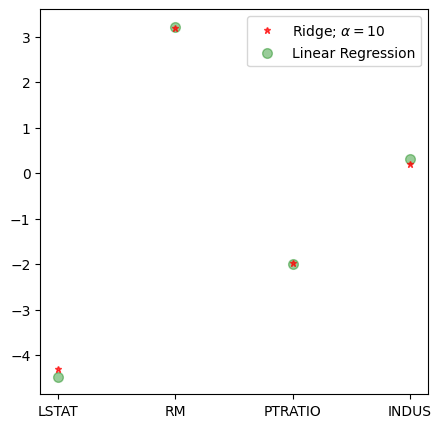

In [7]:
features = X.columns

plt.figure(figsize = (5, 5))
plt.plot(features, ridge.coef_, alpha = 0.7, linestyle = 'none' , marker = '*', markersize = 5, color = 'red', label = r'Ridge; $\alpha = 10$', zorder = 7)
plt.plot(features, ols.coef_, alpha = 0.4, linestyle = 'none', marker = 'o', markersize = 7, color = 'green', label = 'Linear Regression')
plt.xticks(rotation = 0)
plt.legend()
plt.show()

#### Метод градиентного спуска

Эту же задачу можно решить методом градиентного спуска. Функция потерь в этом
случае будет иметь вид

$$ J({\theta_j}) = \frac{1}{2n} \sum (\mathbf y-\boldsymbol \theta \mathbf X)^2 +
\frac{1}{2n} \lambda \boldsymbol \theta^\top \boldsymbol \theta $$

Для градиентного спуска, чтобы не запутаться, обозначим коэффициент скорости
обучения через $\alpha,$ а параметр регуляризации через $\lambda.$ При этом
градиент будет равен

$$ \frac{\partial}{\partial \theta_j} J(\boldsymbol \theta) = \left( -x_j(\mathbf y-\mathbf
X \boldsymbol \theta) + \lambda \boldsymbol \theta \right) \times \frac{1}{n} $$

Нормализовывать сдвиг не обязательно (в первую очередь имеют значения
наклоны). Здесь мы это делаем, чтобы упростить код. Перейдем к практике. Начнем
с собственного класса.

In [8]:
class RidgeGD():
  def __init__(self, alpha = 0.0001):
    self.thetas = None
    self.loss_history = []
    self.alpha = alpha

  def add_ones(self, x):
    return np.c_[np.ones((len(x), 1)), x]

  def objective(self, x, y, thetas, n):
    return (np.sum((y - self.h(x, thetas)) ** 2) + self.alpha * np.dot(thetas, thetas)) / (2 * n)

  def h(self, x, thetas):
    return np.dot(x, thetas)

  def gradient(self, x, y, thetas, n):
    return (np.dot(-x.T, (y - self.h(x, thetas))) + (self.alpha * thetas)) / n

  def fit(self, x, y, iter = 20000, learning_rate = 0.05):
    x, y = x.copy(), y.copy()
    x = self.add_ones(x)

    thetas, n = np.zeros(x.shape[1]), x.shape[0]

    loss_history = []

    for i in range(iter):
      loss_history.append(self.objective(x, y, thetas, n))
      grad = self.gradient(x, y, thetas, n)
      thetas -= learning_rate * grad

    self.thetas = thetas
    self.loss_history = loss_history

  def predict(self, x):
    x = x.copy()
    x = self.add_ones(x)
    return np.dot(x, self.thetas)

In [9]:
ridge_gd = RidgeGD(alpha = 0.0001)

ridge_gd.fit(X_train, y_train, iter = 50000, learning_rate = 0.01)

y_pred_train = ridge_gd.predict(X_train)
y_pred_test = ridge_gd.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.255700309301131
test: 5.127682311863072


Сравним с sklearn. Для того чтобы оптимизировать Ridge регрессию методом
градиентного спуска, используем класс SGDRegressor с параметром penalty = ‘l2’.
Кроме того, укажем другие параметры для того, чтобы применяемый алгоритм был
максимально близок к написанному вручную коду.

In [10]:
from sklearn.linear_model import SGDRegressor

ridge_gd = SGDRegressor(loss = 'squared_error',
                        penalty = 'l2',
                        alpha = 0.0001,
                        max_iter = 50000,
                        learning_rate = 'constant',
                        eta0 = 0.001,
                        random_state = 42)

ridge_gd.fit(X_train, y_train)

y_pred_train = ridge_gd.predict(X_train)
y_pred_test = ridge_gd.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.25595467395471
test: 5.120506389637218


#### Выбор $\alpha$
Подобрать оптимальный гиперпараметр регуляризации можно, в частности, с
помощью класса RidgeCV, который одновременно выполнит оценку качества
модели с помощью перекрестной валидации.

Приведем пример.

In [11]:
from sklearn.linear_model import RidgeCV

# укажем параметры регуляризации alpha, которые хотим протестировать
# дополнительно укажем количество частей (folds), параметр cv,
# на которое нужно разбить данные при оценке качества модели
ridge_cv = RidgeCV(alphas = [0.1, 1.0, 10], cv = 10)
ridge_cv.fit(X_train, y_train)

# выведем оптимальный параметр и достигнутое качество
ridge_cv.alpha_, ridge_cv.best_score_

(np.float64(10.0), np.float64(0.6482859868459572))

#### Байесовская Ridge регрессия

В обычной линейной регрессии мы стремимся получить точечную оценку (point
estimate) параметров $ \boldsymbol \theta $ модели

$$ y = \mathbf x^\top \boldsymbol \theta + \varepsilon, \varepsilon \sim \mathcal{N}(0,
\sigma^2), $$

используя аналитическое решение, метод градиентного спуска или метод
максимального правдоподобия.

В последнем случае мы выбираем такие $\boldsymbol \theta,$ которые, с учётом
имеющихся данных $\mathbf x,$ максимизируют вероятность $y.$

$$ \max P(y \mid \mathbf x, \boldsymbol \theta) $$

**Байесовская линейная регрессия** (Bayesian linear regression) позволяет учесть
априорное знание о параметрах $\boldsymbol \theta,$ рассматривая каждый
параметр не как точечную оценку, а как вероятностное распределение
$P(\boldsymbol \theta).$

Апостериорную вероятность параметров можно найти по формуле Байеса.

$$ P(\boldsymbol \theta \mid \mathbf x, y) = \frac{P(y \mid \mathbf x, \boldsymbol
\theta) \; P(\boldsymbol \theta)}{P(\mathbf x, y)} $$

Предположим для простоты, что значение каждого из параметров $\theta$ следует
нормальному закону с нулевым средним,

$$ P(\boldsymbol \theta) \sim \mathcal{N} (\mathbf 0, \mathbf T), $$

где $\boldsymbol \theta \in \mathbb{R}^d$ и $\mathbf T = \tau \mathbf I_d \in
\mathbb{R}^{d \times d} $ для некоторого числа $\tau.$ Правдоподобие всех
данных также нормально распределено,

$$ P(\mathbf y \mid \mathbf x, \boldsymbol \theta) \sim \mathcal{N} (\mathbf y \mid
\mathbf X \boldsymbol \theta, \sigma^2 \mathbf I), $$

при этом $\mathbf y \in \mathbb{R}^n$ и $\sigma^2 \mathbf I_n \in \mathbb{R}^{n
\times n}$ для некоторого числа $\sigma^2.$

Найдем апостериорное распределение $\log P(\boldsymbol \theta \mid \mathbf X,
\mathbf y).$

$$ \begin{align} & \propto \: \log P (\mathbf y \mid \mathbf X, \boldsymbol \theta) + \log
P(\boldsymbol \theta) \\ & = \: \log \prod^n_{i=1} \frac{1}{\sqrt{2 \pi \sigma^2}} \exp
\left( -\frac{(y_i-(\theta_0x_{i0}+\theta_1x_{i1}+\ldots+\theta_d x_{id}))^2}
{2\sigma^2} \right) \\ & + \: \log \prod^d_{j=0} \frac{1}{\sqrt{2\pi T_j}} \exp \left( -
\frac{\theta_j^2}{2 T_j} \right) \\ & = \: -\sum^n_{i=1} \frac{(y_i-
(\theta_0x_{i0}+\theta_1x_{i1}+\ldots+\theta_d x_{id}))^2}{2\sigma^2}-\sum^d_{j=0}
\frac{\theta^2_j}{2T_j} + const \\ & = -\frac{1}{2\sigma^2} || \mathbf y-\mathbf X
\boldsymbol \theta ||^2_2-\frac{1}{2} \boldsymbol \theta^\top \mathbf T^{-1}
\boldsymbol \theta + const \\ & = -\frac{1}{2\sigma^2} (\mathbf y^\top \mathbf y-
\mathbf X^\top \mathbf y \boldsymbol \theta-\boldsymbol \theta^\top \mathbf X^\top
\mathbf y+\boldsymbol \theta^\top \mathbf X^\top \mathbf X \boldsymbol \theta)-
\frac{1}{2} \boldsymbol \theta^T \mathbf T^{-1} \boldsymbol \theta + const \\ & = -
\frac{1}{2} \left( \boldsymbol \theta^\top \mathbf T^{-1} \boldsymbol \theta + \frac{1}
{\sigma^2} \boldsymbol \theta^\top \mathbf X^\top \mathbf X \boldsymbol \theta-
\frac{2}{\sigma^2} \mathbf X^\top \mathbf y \boldsymbol \theta \right) + const \\ & =-
\frac{1}{2} \left( \boldsymbol \theta^\top \left( \frac{1}{\sigma^2} \mathbf X^\top
\mathbf X + \mathbf T^{-1} \right) \boldsymbol \theta-\frac{2}{\sigma^2} \mathbf
X^\top \mathbf y \boldsymbol \theta \right) + const \end{align} $$

Положим $\boldsymbol \Sigma^{-1} = \frac{1}{\sigma^2} \mathbf X^\top \mathbf X +
\mathbf T^{-1},$ $\boldsymbol \mu = \frac{1}{\sigma^2} \boldsymbol \Sigma \mathbf
X^\top \mathbf y. $ Тогда,

$$ \log P(\boldsymbol \theta \mid \mathbf X, \mathbf y) = -\frac{1}{2} (\boldsymbol
\theta-\boldsymbol \mu)^\top \boldsymbol \Sigma^{-1} (\boldsymbol \theta-\boldsymbol\mu) + const $$

Таким образом, апостериорное распределение определяется нормальным законом

$$ \begin{split} P (\boldsymbol \theta \mid \mathbf X, \mathbf y) \sim & \; \mathcal{N}
(\boldsymbol \theta \mid \boldsymbol \mu, \boldsymbol \Sigma), \quad \text{где} \\
\boldsymbol \mu = & \; \boldsymbol \Sigma \left( \frac{1}{\sigma^2} \mathbf X^\top
\mathbf y \right) \\ \boldsymbol \Sigma = & \; \left( \frac{1}{\sigma^2} \mathbf X^\top
\mathbf X + \mathbf T^{-1} \right)^{-1} \end{split} $$

В случае если априорное нормальное распределение имеет среднее $\boldsymbol
\mu_0,$ отличное от нуля, то среднее апостериорного нормального распределения
можно найти по формуле

$$ \boldsymbol \mu = \boldsymbol \Sigma \left( \mathbf T^{-1} \boldsymbol \mu_0 +
\frac{1}{\sigma^2} \mathbf X^\top \mathbf y \right) $$

Интересно, что задача поиска апостериорного максимума (с нормальным
априорным распределением и нулевым средним значением)

$$ \underset{\theta}{\operatorname{argmax}} P(\boldsymbol \theta \mid \mathbf X,
\mathbf y) = -\frac{1}{2} || \mathbf y-\mathbf X \boldsymbol \theta ||^2_2-\frac{1}
{2\tau} \boldsymbol \theta^\top \boldsymbol \theta $$

аналогична, положив $\alpha = \frac{1}{\tau},$ задаче минимизации линейной
регрессии с L2 регуляризацией

$$ \begin{split} \underset{\theta}{\operatorname{argmin}} J (\boldsymbol \theta) =& \:
\frac{1}{2} || \mathbf y-\mathbf X \boldsymbol \theta ||^2_2+\frac{\alpha}{2}
\boldsymbol \theta^\top \boldsymbol \theta \\ =& \: \frac{1}{2} || \mathbf y-\mathbf X
\boldsymbol \theta ||^2_2 + \frac{\alpha}{2} \sum^d_{j=0} \theta_j^2 \end{split} $$

с тем отличием, что в данном случае регуляризация также затрагивает сдвиг
$\theta_0.$ Остается найти MAP-оценку. Вначале найдем производную.

$$ \begin{split} \log P(\boldsymbol \theta \mid \mathbf X, \mathbf y) &= -\frac{1}{2}
(\mathbf y-\mathbf X \theta)^\top \boldsymbol \Sigma^{-1}(\mathbf y-\mathbf X
\boldsymbol \theta)-\frac{1}{2} \boldsymbol \theta^\top \mathbf T^{-1} \boldsymbol\theta \\ \frac{\partial}{\partial \theta} \log P(\boldsymbol \theta \mid \mathbf X, \mathbf
y) &= \mathbf X^\top \boldsymbol \Sigma^{-1}(\mathbf y-\mathbf X \boldsymbol
\theta)-\mathbf T^{-1} \boldsymbol \theta \end{split} $$

Приравняв производную к нулю, получим

\begin{split} \hat{ \boldsymbol \theta}_{MAP} &= \left(\mathbf X^\top \boldsymbol
\Sigma^{-1} \mathbf X + \mathbf T^{-1} \right)^{-1} \mathbf X^\top \boldsymbol
\Sigma^{-1} \mathbf y \\ &= \left( \frac{1}{\sigma^2} \mathbf X^\top \mathbf X +
\frac{1}{\tau} \mathbf I \right)^{-1} \frac{1}{\sigma^2} \mathbf X^\top \mathbf y.
\end{split}

Приведем код на Питоне.


In [12]:
class BayesianRidgeRegression:

  def __init__(self):
    self.thetas = None

  def fit(self, X, y, sigma_squared, tau):

    X = X.copy()
    X = self.add_ones(X)

    XtX = np.dot(X.T, X)/sigma_squared
    I = np.eye(X.shape[1])/tau
    inverse = np.linalg.inv(XtX + I)
    Xty = np.dot(X.T, y)/sigma_squared
    self.thetas = np.dot(inverse , Xty)

    return self

  def predict(self, X):
    X = self.add_ones(X)
    return np.dot(X, self.thetas)

  def add_ones(self, x):
    return np.c_[np.ones((len(x), 1)), x]

Оценим $\sigma^2$ методом наименьших квадратов.

$$ \hat{\sigma}^2 = \frac{1}{n} (\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top
(\mathbf y-\mathbf X\hat{\boldsymbol \theta}) $$

In [13]:
ols = LinearRegression()
ols.fit(X_train, y_train)

# объединим коэффициенты в один вектор
thetas = np.insert(ols.coef_, 0, ols.intercept_)
# добавим столбец из единиц
X_ones = np.c_[np.ones((len(X_train), 1)), X_train]
# найдем остатки модели и
error = y_train-np.dot(X_ones, thetas)
# среднюю сумму квадратов остатков (MSE)
sigma_squared = np.dot(error, error.T) * (1/len(X_ones))
sigma_squared

np.float64(27.622385741142978)

Обучим модель байесовской линейной регрессии.

In [14]:
tau = 10
br = BayesianRidgeRegression()
y_pred = br.fit(X_train, y_train, sigma_squared, tau).predict(X_test)

In [15]:
root_mean_squared_error(y_test, y_pred)

5.123898119576303

In [16]:
br.thetas[1:]

array([-4.42759683,  3.21194508, -1.99009799,  0.28325829])

Сравним с классом BayesianRidge библиотеки sklearn. Особенность реализации
этого алгоритма заключается в том, что гиперпараметры $\sigma^2$ и $\tau$
определяются моделью на основе переданных ей данных.

In [17]:
from sklearn.linear_model import BayesianRidge
bayes_ridge = BayesianRidge()
bayes_ridge.fit(X_train, y_train)

BayesianRidge()

In [18]:
bayes_ridge.coef_

array([-4.41933248,  3.21064175, -1.98855016,  0.27704705])

### Lasso Regression (L1 regularization)
Регрессия Lasso для регуляризации использует сумму весов по модулю, то есть L1-норму.

$$ J_{Lasso}(\boldsymbol \theta) = MSE + \alpha \cdot || \boldsymbol \theta ||_1 $$

### Сравнение L1 и L2 регуляризации

Различие двух подходов заключается в том, что Ridge-регрессия при возведении
$\theta$ в квадрат сильнее «наказывает» за большие коэффициенты, Lasso
«наказывает» все коэффициенты одинаково. Например, если $\boldsymbol \theta$
равен $ \begin{bmatrix} 10 & 5 \end{bmatrix}^\top $, то в случае L2-регрессии
penalty составит $ 10^2 + 5^2 = 125 $, а в случае L1, только 15. При увеличении
первого коэффициента на единицу L2-penalty составит $ 11^2 + 5^2 = 146 $, L1
увеличится до 16.

Одновременно этот пример показывает особую важность масштабирования
признаков при использовании алгоритма с регуляризацией.

####Обнуление коэффициентов
L1 регуляризация может полностью обнулить часть коэффициентов и, таким
образом, исключить соответствующие признаки из модели. Эта особенность Lasso
регрессии называется parameter sparcity.
#### Математика
Вначале рассмотрим модель с L2-регуляризацией с одним признаком и одним
коэффициентом $\theta$.

$$ L_2 = (y-x\theta)^2+\alpha\theta^2 = y^2-2xy\theta+x^2\theta^2+\alpha\theta^2 $$
Найдем производную относительно $\theta$, приравняем ее к нулю и решим для
$\theta$.
$$ \frac{\partial L_2}{\partial \theta} = -2xy + 2x^2\theta + 2\alpha\theta $$

$$ -2xy + 2x^2\theta + 2\alpha\theta = 0 $$

$$ \theta(x^2 + \alpha ) = xy $$

$$ \theta = \frac{xy}{(x^2 + \alpha)} $$

Коэффициент $\theta$ превратится в ноль для ненулевых значений $x$ и $y$ при
$\alpha \rightarrow \inf$. Сравним с L1-регуляризацией. Найдем производную
относительно $\theta,$ приравняем к нулю и решим для $\theta$ для случаев $\theta
> 0$ (в точке ноль производная функции не определена).

$$ \frac{\partial L_1}{\partial \theta} = -2xy + 2x^2\theta + \alpha $$

$$ -2xy + 2x^2\theta + \alpha = 0 $$

$$ 2x^2\theta = 2xy-\alpha $$

$$ \theta = \frac{2xy-\alpha}{2x^2} $$

Сдалаем то же самое для случая, когда $\theta < 0$.

$$ \frac{\partial L_1}{\partial \theta} = -2xy + 2x^2\theta-\alpha $$

$$ -2xy + 2x^2\theta-\alpha = 0 $$

$$ 2x^2\theta = (\alpha + 2xy) $$

$$ \theta = \frac{\alpha + 2xy}{2x^2} $$

В обоих случаях при определенных $x$, $y$ и $\alpha$ параметр $\theta$ может
быть равен нулю.

Дополнительно сравним L2 и L1 нормы двух векторов $ \begin{bmatrix} 1 \\ 0
\end{bmatrix} $ и $ \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}}
\end{bmatrix} $.

В случае L2-нормы, их длина будет равна единице. В случае L1-нормы длина
первого вектора будет равна единице, а второго $\sqrt{2} \approx 1,41$. Таким образом, L1 регуляризация не только допускает, но и способствует обнулению
коэффициентов.
#### Визуализация
Приведем визуализацию границ двух видов регуляризации из книги T. Hastie *The
Elements of Statistical Learning*.

![](https://drive.google.com/uc?export=view&id=17z9tp1Q3wEbcCKl_xZB5lvZRJgp-VwZJ)

Изолинии отображают уровни ошибки при определенных параметрах $\theta$.
Синий ромб и круг задают соответственно границу L1 и L2 регуляризации.
#### Метод координатного спуска
Как уже было замечено, производная функции абсолютной величины не определена
в точке $x = 0$ и, как следствие, мы не можем использовать обычный алгоритм
градиентного спуска.

При этом мы можем на каждой итерации двигаться вниз вдоль одной из координат
и остановиться, если этот шаг окажется меньше, чем некоторое заданное нами
пороговое значение. Такой метод называется **методом координатного спуска**
(coordinate descent method).

Приведем иллюстрацию из Википедии (https://en.wikipedia.org/wiki/Coordinate_descent).

![](https://drive.google.com/uc?export=view&id=15pepdsX7E1sXZw4Kdh6u_mG41woEnU9l)

Примечание. Обратим внимание, что в данном случае $x$ и $y$ обозначают веса
или коэффициенты, а не данные. Такая нотация принята в литературе по
оптимизации.

Выбрать, по какой координате спускаться можно разными способами, в частности,
можно:
* выбирать признак (координату) случайным образом; или
* просто идти от признака 0 до $j$ (далее признаки мы будем обозначать
именно так).

Рассмотрим, как координатный спуск выглядит с точки зрения математики.




#### Математика
Итак, напомню, функция потерь будет иметь вид

$$ J_{Lasso}(\boldsymbol \theta) = MSE + \alpha \cdot || \boldsymbol \theta ||_1 $$

Вначале обратимся к первому компоненту, а именно MSE. Вспомним, чему равен
градиент MSE.

$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{n} \cdot \left( -x_j(\mathbf y-\mathbf
X\boldsymbol \theta) \right) $$

Перепишем $\mathbf y-\mathbf X\boldsymbol \theta$ как $y-
(\theta_kX_k+\theta_jx_j)$.

$$ \frac{1}{n} \cdot \left( -x_j(y-(\theta_kX_k+\theta_jx_j)) \right) $$

Другими словами, выделим ту координату $j$ (признак), по которой мы будем
спускаться на конкретной итерации. $\theta_kX_k$ — это прогноз модели без
коордианты $j$. Раскроем, а затем реорганизуем скобки.

$$ \frac{1}{n} \cdot \left( -x_j((y-\theta_kX_k)-\theta_jx_j) \right) $$

Умножим $-x_j$ на каждое из слагаемых.

$$ \frac{1}{n} \cdot \left( -x_j(y-\theta_kX_k) + \theta_j x_j^2 \right) $$

Обозначим компоненты через новые переменные $\rho$ («ро») и $z$.

$$ \rho_j = x_j(y-\theta_kX_k) $$

Примечание. Минус перед $x_j$ появится в окончательной формуле ниже.

$$ z_j = x_j^2 $$

Переменная $\rho$ показывает, насколько признак $x_j$ коррелирует с остатками модели $y-\theta_kX_k,$ построенной без $j.$ Если $\rho$ (т.е.
корреляция) растет, значит этот признак важен для модели, и его вес стоит
увеличить.

Тогда выражение будет иметь вид

$$ \frac{\partial L}{\partial \theta_j} = -\frac{1}{n}\rho_j + \frac{1}{n} \theta_jz_j $$

Приравняв производную к нулю, найдем решение относительно $\theta_j.$

$$ \theta_j = \frac{\rho_j}{z_j} $$

Замечу, что $z_j,$ то есть скалярное произведение вектора признака $x_j$ на самого
себя, будет равно единице, если признаки будут предварительно нормализованы
(приведены к единичной L2 норме).

Обратимся ко второму компоненту — слагаемому регуляризации. Так как
производная в точке $|\theta_j| = 0$ не определена, воспользуемся таким понятием
как **субградиент** (subgradient). По сути, субградиентом является множество
возможных градиентов в определенной точке. Приведем иллюстрацию для
субградиентов в точке $|\theta_j| = 0$.
![](https://drive.google.com/uc?export=view&id=1r_l8wk42IaELsTWdVnq2YtSCVFg0Gy_Q)

Как видно, субградиенты могут принимать значения $[-1, 1]$ (градиенты функции
абсолютного значения) или вернее от $[-\alpha, \alpha]$, то есть параметра, на
который мы умножаем слагаемое регуляризации.

$$ \alpha \frac{\partial |\theta_j|}{\partial \theta_j} = \left\{ \begin{matrix} -\alpha &
\text{when } \theta_j < 0 \\ [-\alpha, \alpha] & \text{when } \theta_j = 0 \\ \alpha &
\text{when } \theta_j < 0 \end{matrix} \right. $$

Объединим две производные.

$$ \frac{\partial L(\theta)}{\partial \theta_j} = -\frac{1}{n} \rho_j + \frac{1}{n} \theta_j
z_j + \left\{ \begin{matrix} -\alpha & \text{when } \theta_j < 0 \\ [-\alpha, \alpha] &
\text{when } \theta_j = 0 \\ \alpha & \text{when } \theta_j < 0 \end{matrix} \right. $$

Рассмотрим каждый из трех случаев по отдельности.

**Вариант 1.** $\theta_j < 0$

$$ -\frac{1}{n}\rho_j + \frac{1}{n} \theta_jz_j-\alpha = 0 $$

$$ \theta_j = \frac{\rho_j + n\alpha}{z_j} $$

Для того чтобы $\theta_j < 0$, необходимо чтобы $\rho_j < n\alpha. $

**Вариант 2.** $\theta_j = 0$

$$ -\frac{1}{n}\rho_j + \frac{1}{n} \theta_jz_j + [-\alpha, \alpha] = 0 $$

$$ \theta_j = \left[ \frac{\rho_j-n\alpha}{z_j}, \frac{\rho_j + n\alpha}{z_j} \right] $$

Для того чтобы $ \theta_j = 0 $, $ -n\alpha\ \leq \rho_j \leq n\alpha. $

**Вариант 3**. $\theta_j > 0$

$$ -\frac{1}{n}\rho_j + \frac{1}{n} \theta_jz_j + \alpha = 0 $$

$$ \theta_j = \frac{\rho_j-n\alpha}{z_j} $$

Для того чтобы $\theta_j > 0$, $\rho_j > n\alpha. $

Сдвиг $\theta_0$ не регуляризуется и изменяется с помощью частной производной
MSE (первое слагаемое).

$$ \theta_0 = \frac{\rho_0}{z_0} $$

Таким образом, шаги алгоритма координатного спуска будут следующими:

**Шаг 1.** Добавить первый (!) столбец из единиц для коэффициента $\theta_0$.
Инициализировать веса $\theta$;

**Шаг 2.** Рассчитать $z_j$;
$$ z_j = \sum x_j^2 $$

**Шаг 3.** Задать начальный максимальный размер шага (max_step) и пороговое
значение (tolerance);

**Шаг 4.** Пока максимальный размер шага больше порогового значения проходиться
в цикле по каждой из координат (признаку), рассчитывать $ \rho_j = \sum x_j((y-
\theta_kX_k) $ и обновлять вес $\theta$ этого признака в соответствии со следующими правилами.

Если $j = 0,$ то есть речь идет о первом по счету коэффициенте $\theta_0,$ то
$\theta_j = \frac{ρ_j}{z_j}.$ В остальных случаях:

$$ \theta_j = \left\{ \begin{array}{ll} \frac{\rho_j + n \alpha}{z_j} & \text{if} & \rho_j <
-n \alpha \\ 0 & \text{if} & -n \alpha ≤ \rho_j ≤ n \alpha \\ \frac{\rho_j-n \alpha}{z_j} &
\text{if} & \rho_j > n \alpha \end{array} \right. $$

Обратите внимание, если $ -n\alpha\ \leq \rho_j \leq n\alpha $ (то есть корреляция
признака очень мала по модулю), то коэффициент будет обнулен и исключен из
модели. В двух других случаях (варианты 1 и 3), мы будем увеличивать
коэффициент при большом отрицательном $\rho_j$ и уменьшать при большом
положительном (т.е. выполнять регуляризацию).

Посмотрим на график ниже.
![](https://drive.google.com/uc?export=view&id=1LbVmDkYjlyaDck09av8b2hC7EhuI2J56)

Такое ограничение называется мягким порогом (soft thresholding). Для сравнения
приведем Ridge регрессию, которая сокращает коэффициенты на всем диапазоне
$\theta$, но не приводит их к нулевым значениям.

#### Метод координатного спуска
#### Реализация на Питоне
Объявим вспомогательные функции.


In [19]:
# добавим столбец из единиц в матрицу признаков
def add_ones(x):
  return np.c_[np.ones((len(x), 1)), x]

# объявим функцию гипотезы
def h(x, theta):
  # 506 х (4 + 1) на (4 + 1) х 1
  return np.dot(x, theta) # 506 x 1

# рассчитаем rho_j
def rho(y, x, theta, j):
  # удалим признак (координату) j из матрицы признаков и вектора весов
  x_k = np.delete(x, j, 1)
  theta_k = np.delete(theta ,j)
  # сделаем прогноз без j
  y_pred_k = h(x_k, theta_k)
  # найдем остатки при прогнозе без j
  residuals_k = y - y_pred_k
  # вычислим rho_j
  rho_j = np.sum(x[:,j] * residuals_k)
  return rho_j

# рассчитаем z
def compute_z(x):
  # рассчитаем z (т.е. L2 норму) для каждого столбца (axis = 0)
  z_vector = np.sum(x * x, axis = 0)
  return z_vector

Объявим функцию координатного спуска.

In [20]:
def coordinate_descent(x, y, alpha = 0.1, tolerance = 0.0001):

  x = add_ones(x)
  theta = np.zeros(x.shape[1], dtype = float)

  z = compute_z(x)

  max_step = 100.
  iterations = 0

  # tolerance - пороговое значение, если шаг меньше, остановимся
  while(max_step > tolerance):
    iterations += 1
    old_theta = np.copy(theta)

    # поочередно выберем каждый из признаков
    for j in range(len(theta)):

      # рассчитаем rho_j
      rho_j = rho(y, x, theta, j)

      # пропишем обновление для сдвига (первый по счету коэффициент)
      if j == 0:
        theta[j] = rho_j / z[j]

      # пропишем обновления для остальных признаков
      elif rho_j < -alpha * len(y):
        theta[j] = (rho_j + (alpha * len(y))) / z[j]

      elif rho_j > -alpha * len(y) and rho_j < alpha * len(y):
        theta[j] = 0.

      elif rho_j > alpha * len(y):
        theta[j] = (rho_j - (alpha*len(y))) / z[j]

    # запишем текущий максимальный для всех координат (!!!) размер шага
    # (обратите внимание, код ниже выполняется после цикла for)
    step_sizes = abs(old_theta - theta)
    max_step = step_sizes.max()

  return theta, iterations, max_step

Протестируем алгоритм.

In [21]:
theta_opt, iterations, max_step = coordinate_descent(X_train, y_train,
                                                     alpha = 0.2,
                                                     tolerance = 0.0001)

np.set_printoptions(precision = 3, suppress = True)

print("Intercept is:",theta_opt[0])
print("\nCoefficients are:\n",theta_opt[1:])
print("\nNumber of iterations is:", iterations)

Intercept is: 23.01581920903955

Coefficients are:
 [-4.228  3.107 -1.811  0.   ]

Number of iterations is: 11


Мы видим, что модель сочла признак INDUS не имеющим значения для данной
модели и обнулила соответствующий коэффициент. Сравним с классом Lasso
библиотеки sklearn.

In [22]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 0.2, tol = 0.0001)
lasso.fit(X_train, y_train)

print("sklearn Lasso intercept :",lasso.intercept_)
print("\nsklearn Lasso coefficients :\n",lasso.coef_)
print("\nsklearn Lasso number of iterations :",lasso.n_iter_)

sklearn Lasso intercept : 23.01581920903955

sklearn Lasso coefficients :
 [-4.228  3.107 -1.811  0.   ]

sklearn Lasso number of iterations : 10


#### Байесовская Lasso регрессия

Выше мы показали, что L2 регуляризация линейной регрессии практически
идентична апостериорному распределению $ P(\boldsymbol \theta \mid \mathbf X,
\mathbf y) $ с нормальным априорным распределением параметров с нулевым
средним значением.

Интересно, что L1 регуляризация аналогична вероятностной модели, в которой
априорное распределение параметров подчиняется распределению Лапласа (Laplace
distribution).

$$ P(\boldsymbol \theta) \sim Laplace (\mu, b) = \frac{1}{2b} \exp \left( -
\frac{\boldsymbol \theta-\mu}{b} \right), \; \mu=0$$



Посмотрим на плотность вероятности.

Распределение Лапласа

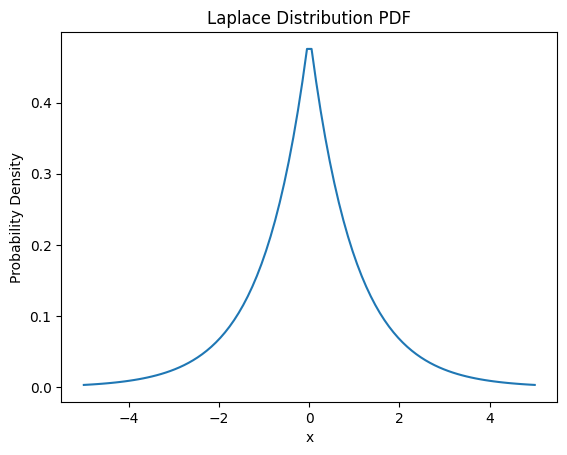

In [23]:
from scipy.stats import laplace
loc_param = 0
scale_param = 1

x_values = np.linspace(-5, 5, 100)
pdf_values = laplace.pdf(x_values, loc=loc_param, scale=scale_param)

plt.plot(x_values, pdf_values)
plt.title('Laplace Distribution PDF')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.show()

Найдем апостериорный максимум $\hat{\boldsymbol \theta}_{MAP}.$

$$ \begin{split} =& \: \underset{\theta}{\operatorname{argmax}} \log P (\mathbf y \mid
\mathbf X, \boldsymbol \theta) + \log P(\boldsymbol \theta) \\ =& \: \underset{\theta}
{\operatorname{argmax}} \bigg( \log \prod^n_{i=1} \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left( -\frac{(y_i-(\theta_0x_{io}+\theta_1x_{i1}+\ldots+\theta_dx_{id}))^2}
{2\sigma^2} \right) \\ &\hspace{2.3cm} + \log\prod^d_{j=0} \frac{1}{2b} \exp\left(-
\frac{\theta_j}{b}\right) \bigg) \\ =& \: \underset{\theta}{\operatorname{argmax}} \bigg(
-\frac{n}{2}\log(2\pi\sigma^2)-\frac{1}{2\sigma^2} \sum^n_{i=1}(y_i-
(\theta_0x_{io}+\theta_1x_{i1}+\ldots+\theta_dx_{id}))^2 \\ &\hspace{2.3cm} + d \log\frac{1}{2b}-\sum^d_{j=0} \frac{|\theta_j|}{b} \bigg) \\ =& \: \underset{\theta}
{\operatorname{argmin}} \frac{1}{2\sigma^2} \bigg( \sum^n_{i=1} (y_i-
(\theta_0x_{io}+\theta_1x_{i1}+\ldots+\theta_dx_{id}))^2 \\ &\hspace{2.3cm} +
\frac{2\sigma^2}{b} \sum{d}{j=0}|\theta_j| \bigg) \\ =& \: \underset{\theta}
{\operatorname{argmin}} \left( \Vert y-\mathbf X\boldsymbol \theta
\Vert^2_2+\alpha\Vert\boldsymbol \theta \Vert_1 \right) \end{split} $$

Как и в случае с нормальным априорным распределением, MAP-оценка с
априорным распределением Лапласа предполагает регуляризацию сдвига
$\theta_0.$

На Питоне байесовскую Lasso регрессию можно реализовать с помощью
библиотеки вероятностного программирования (probabilistic programming, PP)
**PyMC.**


библиотека PyMC

In [24]:
import pymc as pm
import arviz as az

In [25]:
# создадим объект класса Model
model = pm.Model()

# внутри этого объекта зададим
with model:
  # априорное нормальное распределение для сдвига и
  intercept = pm.Normal('intercept', mu=0, sigma=10)
  # априорное распределение Лапласа для остальных коэффициентов
  thetas = pm.Laplace('thetas', mu=0, b=1, shape=X_train.shape[1])

  # пропишем линейную модель
  mu = intercept + pm.math.dot(X_train, thetas)

  # зададим правдоподобие, в котором
  # априорное распределение СКО ошибки следует полнормальному закону
  # (случайная величина принимает только положительные значения)
  sigma = pm.HalfNormal('sigma', sigma=1)
  likelihood = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)

  # проведем сэмплирование из апостериорного распределения
  trace = pm.sample(2000, tune=1000, chains=2, cores=1, random_seed=42)

Output()

Апостериорное распределение параметров можно посмотреть с помощью
библиотеки Arviz.

In [26]:
z.summary(trace, var_names=['thetas', 'intercept', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
thetas[0],-4.374,0.390,-5.067,-3.601,0.006,0.006,4572.0,2648.0,1.0
thetas[1],3.171,0.358,2.464,3.798,0.005,0.006,5011.0,3142.0,1.0
thetas[2],-1.924,0.295,-2.461,-1.352,0.004,0.004,4649.0,3094.0,1.0
thetas[3],0.183,0.308,-0.359,0.793,0.005,0.005,4338.0,3120.0,1.0
intercept,22.998,0.265,22.536,23.512,0.004,0.004,5124.0,2810.0,1.0
sigma,5.119,0.183,4.765,5.453,0.003,0.003,5170.0,3245.0,1.0


Поясним, что столбец mean содержит матожидание каждого из оцениваемых
параметров.

Столбцы hdi_3% и hdi_97% содержат соответственно левую и правую границы 94%
**интервала наибольшей плотности** (highest density interval, HDI) апостериорного
распределения, т.е. наиболее узкий байесовский доверительный интервал (credible
interval), содержащий заданную плотность распределения.

Другими словами, это наименьший интервал, в котором с вероятностью (в данном
случае) 94% содержится истинное значение параметра.

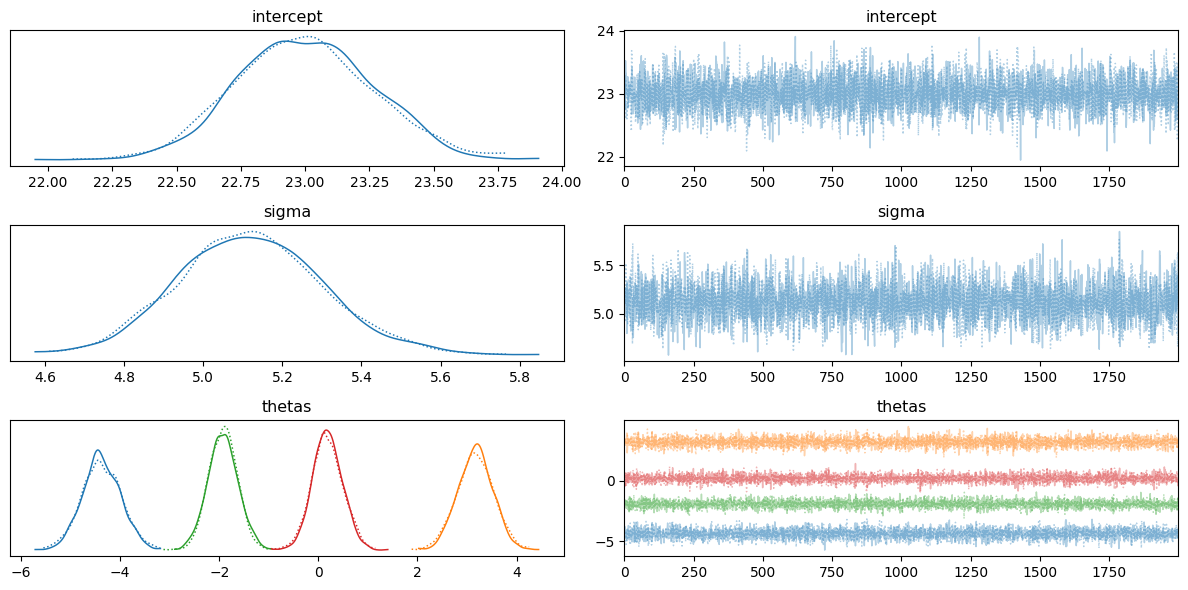

In [27]:
axes = az.plot_trace(trace)
fig = plt.gcf()
fig.tight_layout()
plt.show()

Мы также можем посмотреть граф созданной нами модели.

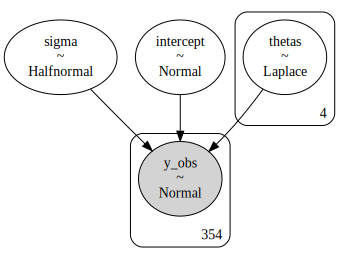

In [28]:
pm.model_to_graphviz(model)

При изучении байесовской Ridge регрессии мы нашли оптимальные
$\hat{\boldsymbol \theta}$ с помощью MAP-оценки и после этого получили
прогнозные значения для тестовых данных через $\mathbf X_{test} \hat{\boldsymbol
\theta}_{MAP}.$

Одновременно, имея апостериорное распределение параметров $\boldsymbol \theta,$
мы могли бы сделать прогноз через **прогнозное апостериорное распределение**
(posterior predictive distribution)

$$ P(y’ \mid \mathbf x, y, \mathbf x’) = \int_{\theta \in \Theta} P(y’ \mid \mathbf x’,
\boldsymbol \theta ) P(\boldsymbol \theta \mid \mathbf x, y) d \boldsymbol \theta $$

то есть распределение новых, еще не знакомых нам данных $\mathbf x’, y’.$

In [29]:
# в том же классе
with model:
  # создадим еще одну линейную модель с уже известным распределением параметров thetas и
  # новыми данными X_test
  new_mu = intercept + pm.math.dot(X_test, thetas)
  # распределение СКО ошибки будет тем же
  new_sigma = sigma
  # зададим правдоподобие с учетом новых данных y_test и
  new_likelihood = pm.Normal('new_y_obs', mu=new_mu, sigma=new_sigma, observed=y_test)
  # проведем сэмплирование из апостериорного распределения
  new_trace = pm.sample_posterior_predictive(trace)

Output()

In [30]:
# для каждого наблюдения мы сформировали апостериорное прогнозное распределение,
# матожидание каждого из этих распределений и будет прогнозным значением
y_pred = new_trace.posterior_predictive['new_y_obs'].mean(('chain','draw'))

In [31]:
root_mean_squared_error(y_test, y_pred)

5.109230866897803

Подробное рассмотрение библиотеки PyMC выходит за рамки этого занятия,
однако заметим, что аналогичным образом мы могли бы задать модель байесовской
Ridge регрессии, изменив априорное распределение $\boldsymbol \theta.$

### Elastic Net Regression

Регрессия Elastic Net использует как L1, так и L2 регуляризацию.

$$ J_{ElasticNet}(\boldsymbol \theta) = MSE + \alpha_1 \cdot || \boldsymbol \theta ||_1 +
\alpha_2 \cdot || \boldsymbol \theta ||_2^2 $$

Так как в этой модели есть компонент L1, для которого в точке $|\theta_j| = 0$
производная не определена, используем один из возможных субградиентов, а
именно нулевой субградиент (красная пунктирная линия $g_3$ на рисунке выше).

Другими словами, субградиент для компонента будет выглядеть следующим
образом

$$ \frac{\partial J_{L1}}{\partial_{sub} \theta} = \left\{ \begin{matrix} 1 & \text{if }
\theta > 0 \\ 0 & \text{if } \theta = 0 \\ -1 & \text{if } \theta < 0 \end{matrix} \right. $$

Это условие соответствует сигнум-функции или функции знака (sign function (https://en.wikipedia.org/wiki/Sign_function)). На
Питоне можно использовать **np.sign()** .

In [32]:
class ElasticNet():
  def __init__(self, a1 = 0.1, a2 = 0.1):
    self.thetas = None
    self.loss_history = []
    self.a1 = a1
    self.a2 = a2

  def add_ones(self, x):
    return np.c_[np.ones((len(x), 1)), x]

  def objective(self, x, y, thetas, n):
    return (np.sum((y - self.h(x, thetas)) ** 2) + self.a1 * np.sum(np.abs(thetas)) + self.a2 * np.dot(thetas, thetas)) / (2 * n)

  def h(self, x, thetas):
    return np.dot(x, thetas)

  def gradient(self, x, y, thetas, n):
    return (np.dot(-x.T, (y - self.h(x, thetas))) + (self.a1 * np.sign(thetas)) + (self.a2 * thetas)) / n

  def fit(self, x, y, iter = 20000, learning_rate = 0.05):
    x, y = x.copy(), y.copy()
    x = self.add_ones(x)

    thetas, n = np.zeros(x.shape[1]), x.shape[0]

    loss_history = []

    for i in range(iter):
      loss_history.append(self.objective(x, y, thetas, n))
      grad = self.gradient(x, y, thetas, n)
      thetas -= learning_rate * grad

    self.thetas = thetas
    self.loss_history = loss_history

  def predict(self, x):
    x = x.copy()
    x = self.add_ones(x)
    return np.dot(x, self.thetas)

In [33]:
elastic = ElasticNet()

elastic.fit(X_train, y_train, iter = 50000, learning_rate = 0.01)

y_pred_train = elastic.predict(X_train)
y_pred_test = elastic.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.255705191138267
test: 5.127348870379186


In [34]:
elastic.thetas

array([23.009, -4.473,  3.219, -1.998,  0.317])

Сравним с классом ElasticNet библиотеки sklearn.

In [35]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.05)
elastic.fit(X_train, y_train)

elastic.fit(X_train, y_train)

y_pred_train = elastic.predict(X_train)
y_pred_test = elastic.predict(X_test)

print('train: ' + str(root_mean_squared_error(y_train, y_pred_train)))
print('test: ' + str(root_mean_squared_error(y_test, y_pred_test)))

train: 5.259317264886122
test: 5.100827371724984


In [36]:
elastic.intercept_, elastic.coef_

(np.float64(23.01581920903955), array([-4.287,  3.179, -1.944,  0.146]))

Замечу, что класс ElasticNet библиотеки sklearn использует координатный спуск для
минимизации функции потерь. Кроме того, в документации можно посмотреть, как
единственный параметр $\alpha$ регулирует значимость L1 и L2 компонентов.

## Регуляризация нейросети
Регуляризация нейросети
В качестве иллюстрации приведем примеры L2 регуляризации нейронной сети.
Реализуем эту модель на основе уже созданного алгоритма бинарной
классификации со смещением с двумя признаками и одним скрытым слоем (три
нейрона) и сравним результаты обучения.

### Функция потерь с регуляризацией

Посмотрим на функцию потерь с учетом регуляризации (бинарная классификация)

$$ J(W) = J_{\text{nn}}(W) + J_{\text{reg}} (W) = $$

$$ -\frac{1}{n} \sum y \cdot log(a^{(L)}) + (1-y) \cdot log(1-a^{(L)}) + $$

$$ + \frac{\lambda}{2n} \sum \sum \sum W^{(l)2} $$

Мы находим уровень ошибки на основе значений выходного слоя $a^{(L)}$. Кроме
того, мы добавляем значение регуляризации, которое рассчитывается как сумма
сумм весов слоев (1) и (2) и контролируется коэффициентом $\lambda.$

Приведем код.

In [37]:
# в коде обозначим коэффициент lambda как reg
def objective(y, y_pred, n, reg):

  y_one_loss = y * np.log(y_pred + 1e-9)
  y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
  log_loss = - np.sum(y_zero_loss + y_one_loss) / n

  # по умолчанию np.sum() складывает по всем измерениям
  reg_loss = (np.sum(W1**2) + np.sum(W2**2)) * reg / (2 * n)

  return log_loss + reg_loss

Градиент компонента регуляризации для слоя $l$ будет иметь вид

$$ \frac{ \partial J_{\text{reg}} }{ \partial W^{(l)} } \left( \frac{\lambda}{2n} W^{(l)2}
\right) = \frac{\lambda}{n} W^{(l)}, $$

и обновление будет происходить согласно

$$ W^{(l)} := W^{(l)}-\frac{\alpha}{n} \left( \frac{\partial J_{\text{nn}} }{\partial
W^{(l)}} + \lambda \frac{\partial J_{\text{reg}} }{\partial W^{(l)}} \right), $$

где $\alpha$ — коэффициент скорости обучения и $\lambda$ — коэффициент
регуляризации. Регуляризация смещения не проводится.

### Подготовка данных

In [38]:
from sklearn import datasets
data = datasets.load_wine()

df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

df = df[df.target != 2]

X = df[['alcohol', 'proline']]
y = df['target']

X = (X - X.mean()) / X.std()

X = X.to_numpy().T
y = y.to_numpy().reshape(1, -1)

### Обучение модели

In [39]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

In [40]:
np.random.seed(33)

W1 = np.random.randn(3, 2)
b1 = np.zeros((3, 1))

W2 = np.random.randn(1, 3)
b2 = np.zeros((1, 1))

n = X.shape[1]

epochs = 100000
learning_rate = 0.1
reg = 0.01

for i in range(epochs):
  # 3 х 2 на 2 х 130
  Z1 = np.dot(W1, X) + b1
  A1 = sigmoid(Z1) # (3 x 130)

  # 1 х 3 на 3 х 130
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2) # (1 x 130)

  loss = objective(A2, y, n, reg)

  W2_delta = A2 - y # (1 x 130)
  W1_delta = np.dot(W2.T, W2_delta) * A1 * (1 - A1) # (3 x 130)

  # 1 х 130 на 130 х 3
  # значение градиента с учетом регуляризации
  W2_derivative = (np.dot(W2_delta, A1.T)  + reg * W2) / n # (1 x 3)
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (1 x 1)

  # 3 х 130 на 130 х 2
  # значение градиента с учетом регуляризации
  W1_derivative = (np.dot(W1_delta, X.T) + reg * W1) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 7.5226588714475175
-----------------------
Эпоха: 20000
Ошибка: 0.9993308610419742
-----------------------
Эпоха: 40000
Ошибка: 0.7671328827231176
-----------------------
Эпоха: 60000
Ошибка: 0.719050078989783
-----------------------
Эпоха: 80000
Ошибка: 0.6941113685192719
-----------------------
Итоговая ошибка 0.6773298143590253
Нейросеть успешно обучена


Сделаем прогноз.

In [41]:
from sklearn.metrics import accuracy_score

Z1 = np.dot(W1, X) + b1
A1 = sigmoid(Z1)
Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2)

y_pred, y_true = A2.flatten() > 0.5, y.flatten()

accuracy_score(y_true, y_pred)

0.9846153846153847

### Регуляризация в библиотеке Keras
Приведем регуляризацию модели в библиотеке Keras.

In [42]:
import tensorflow as tf

In [43]:
np.random.seed(42)
tf.random.set_seed(42)

# регуляризация добавляется на каждый слой
l2_reg = tf.keras.regularizers.l2(0.01)

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True,
                        kernel_regularizer = l2_reg),

  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = True,
                        kernel_regularizer = l2_reg)
])

sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 130,
          verbose = 0)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (130, 3)               │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (130, 1)               │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (64.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [44]:
model.history.history['accuracy'][-1]

0.9538461565971375

В целом регуляризаторы в Keras можно задавать следующим образом.

In [45]:
# l1, l2 и ElasticNet
tf.keras.regularizers.l1(0.)
tf.keras.regularizers.l2(0.)
tf.keras.regularizers.l1_l2(l1 = 0.01, l2 = 0.01)

## Дополнительные материалы

### Бэггинг для снижения разброса

Нам не обязательно использовать прогноз только одной модели. Можно взять
группу или ансамбль (от франц. ensemble — «вместе») моделей. Рассмотрим один
из способов ансамблирования, бэггинг (bagging), и постараемся с его помощью
снизить разброс модели.
#### Про бэггинг
Бэггинг (bagging) или bootstrap agg regat ing предполагает три основных шага:

1. Bootstrapping. За счет случайных выборок с возвращением (random samples
with replacement) создается несколько датасетов на основе исходных данных
(subsets). Это означает, что в каждом датасете могут быть как повторяющиеся
объекты, так и объекты из других датасетов;
2. Parallel training. Затем модели (их называют базовыми моделями, base
estimators, или weak learners) обучаются параллельно и независимо друг от
друга;
3. Aggregation. Наконец, в зависимости от типа задачи, т.е. регрессии или
классификации, рассчитывается, соответственно, среднее значение (soft
voting) или класс, предсказанный большинством (hard/majority voting).

#### Алгоритм решающего дерева
Одним из недостатков алгоритма решающих деревьев (decision trees) как раз
является склонность к переобучению и высокий разброс модели. Посмотрим,
сможет ли бэггинг исправить ситуацию.
#### Подготовка данных
Используем данные о пациентах с диабетом.



In [46]:
diabetes = pd.read_csv('/content/diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [47]:
X = diabetes.drop(columns = 'Outcome')
y = diabetes.Outcome

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42)

In [48]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 10, random_state = 42)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('train: ' + str(accuracy_score(y_train, y_pred_train)))
print('test: ' + str(accuracy_score(y_test, y_pred_test)))

train: 0.9795158286778398
test: 0.696969696969697


In [49]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(estimator = model,
                              n_estimators = 100,
                              # выборка с возвращением
                              bootstrap = True,
                              random_state = 42)

bag_model.fit(X_train, y_train)

y_pred_train = bag_model.predict(X_train)
y_pred_test = bag_model.predict(X_test)

print('train: ' + str(accuracy_score(y_train, y_pred_train)))
print('test: ' + str(accuracy_score(y_test, y_pred_test)))

train: 1.0
test: 0.7532467532467533
